In [1]:
!pip install requests beautifulsoup4 pandas

In [2]:
!pip install transformers torch nltk

In [3]:
import os
os.makedirs('../images', exist_ok=True)

In [4]:

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [5]:
# 1. The Function Definition
def scrape_et_rbi_policy(num_pages=20):
    base_url = "https://economictimes.indiatimes.com/markets/rbi-policy"
    articles = []
    for pg in range(1, num_pages + 1):
        url = f"{base_url}?curpg={pg}"
        res = requests.get(url)
        soup = BeautifulSoup(res.text, "html.parser")
        for entry in soup.find_all("div", class_="eachStory"):
            h3 = entry.find("h3")
            if h3 and h3.find("a"):
                link = "https://economictimes.indiatimes.com" + h3.find("a")["href"]
                title = h3.text.strip()
                summary = entry.find("p").text.strip() if entry.find("p") else ""
                articles.append({"title": title, "url": link, "summary": summary})

        # INCREASED SLEEP TIME to avoid getting blocked on a 20-page pull
        time.sleep(2)

    return pd.DataFrame(articles)

# 2. The Actual Function Call (Execute the Deep Pull)
print("Starting the deep pull... This will take a minute or two.")

# Change this to 20 so it pulls the full history!
df = scrape_et_rbi_policy(num_pages=20)

print(f"Successfully scraped {len(df)} articles.")
print(df.head())

Starting the deep pull... This will take a minute or two.
Successfully scraped 2000 articles.
                                               title  \
0  RBI policy press conference: Here's everything...   
1  Rupee rises 50 paise to 95.24 against US dolla...   
2  Rupee inches up, defies Asian peers; caution p...   
3  R Gandhi calls RBI policy 'on expected lines',...   
4  India bonds end flat as RBI policy caution off...   

                                                 url  \
0  https://economictimes.indiatimes.comhttps://ec...   
1  https://economictimes.indiatimes.comhttps://ec...   
2  https://economictimes.indiatimes.comhttps://ec...   
3  https://economictimes.indiatimes.comhttps://ec...   
4  https://economictimes.indiatimes.comhttps://ec...   

                                             summary  
0  The Reserve Bank of India unveiled new measure...  
1  The rupee strengthened significantly against t...  
2  The Indian rupee strengthened on Friday, defyi...  
3  The Reser

In [6]:
df.to_csv("rbi_policy_news.csv", index=False)


In [7]:
# 1. Clean up the URL duplication bug
df['url'] = df['url'].str.replace("https://economictimes.indiatimes.comhttps://", "https://")

In [8]:
df.head(10)

,title,url,summary
0,RBI policy press conference: Here's everything...,https://economictimes.indiatimes.com/news/econ...,The Reserve Bank of India unveiled new measure...
1,Rupee rises 50 paise to 95.24 against US dolla...,https://economictimes.indiatimes.com/markets/f...,The rupee strengthened significantly against t...
2,"Rupee inches up, defies Asian peers; caution p...",https://economictimes.indiatimes.com/markets/f...,"The Indian rupee strengthened on Friday, defyi..."
3,"R Gandhi calls RBI policy 'on expected lines',...",https://economictimes.indiatimes.com/markets/e...,The Reserve Bank of India has maintained its n...
4,India bonds end flat as RBI policy caution off...,https://economictimes.indiatimes.com/markets/b...,Brent crude and U.S. Treasury yields eased in ...
5,Indian bonds steady as U.S.-Iran tensions ling...,https://economictimes.indiatimes.com/markets/b...,Indian government bonds saw little movement ea...
6,India bonds slip ahead of RBI policy as war ri...,https://economictimes.indiatimes.com/markets/b...,The Reserve Bank of India will announce its ra...
7,"Currency, bond markets await RBI cues from MPC...",https://economictimes.indiatimes.com/markets/f...,The Indian rupee and benchmark bond yields tra...
8,RBI MPC June meet 2026: What's cheaper and wha...,https://economictimes.indiatimes.com/news/econ...,The Reserve Bank of India has maintained the r...
9,RBI MPC Meeting at a Glance: Your one-stop gui...,https://economictimes.indiatimes.com/news/econ...,RBI Monetary Policy Meeting Highlights: Reserv...


In [9]:
df.shape

(2000, 3)

In [10]:
df['summary'].loc[2]

'The Indian rupee strengthened on Friday, defying subdued Asian markets ahead of a key policy decision. While a currency trader noted flow-driven adjustments, overall caution prevails as the Reserve Bank of India prepares to announce its policy, with markets watching for potential rate hikes amid inflation and currency pressures.'

In [11]:
# Count rows where summary is NaN
num_nan = df['summary'].isna().sum()
print("Number of NaN summaries:", num_nan)

Number of NaN summaries: 0


In [12]:
# Number of rows where summary is empty string or only whitespace
num_empty = (df['summary'].str.strip() == '').sum()
print("Number of empty-string summaries:", num_empty)

Number of empty-string summaries: 195


In [13]:
# 1. Filter out the empty strings and whitespace
df_clean = df[df['summary'].str.strip() != ''].copy()

# 2. Filter out any actual NaN/Null values just to be safe
df_clean = df_clean.dropna(subset=['summary'])

print(f"Original dataset size: {len(df)}")
print(f"Clean dataset size: {len(df_clean)}")

# 3. Overwrite your previous variable so the rest of the pipeline uses the clean data
df = df_clean

Original dataset size: 2000
Clean dataset size: 1805


In [14]:
import torch
import numpy as np
import pandas as pd
import nltk
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from nltk.tokenize import sent_tokenize

# 1. Download necessary NLTK data (just sentence boundaries, not stopwords!)
nltk.download('punkt')

# 2. Load the FinBERT Model and Tokenizer into memory
print("Loading FinBERT model into memory...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

# 3. Define the Engine
def get_geopolitical_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 'Neutral', 0.0, 0.0, 0.0

    sentences = sent_tokenize(text)

    geopolitical_keywords = ['iran', 'israel', 'us', 'war', 'conflict', 'middle east',
                             'geopolitical', 'crude', 'oil', 'brent']

    pos_scores, neg_scores, neu_scores = [], [], []

    for sentence in sentences:
        if any(keyword in sentence.lower() for keyword in geopolitical_keywords):
            inputs = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=512)

            with torch.no_grad():
                outputs = model(**inputs)

            probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().tolist()

            pos_scores.append(probs[0])
            neg_scores.append(probs[1])
            neu_scores.append(probs[2])

    if not pos_scores:
        return 'None', 0.0, 0.0, 0.0

    avg_pos = np.mean(pos_scores)
    avg_neg = np.mean(neg_scores)
    avg_neu = np.mean(neu_scores)

    scores = {'Positive': avg_pos, 'Negative': avg_neg, 'Neutral': avg_neu}
    final_label = max(scores, key=scores.get)

    return final_label, avg_pos, avg_neg, avg_neu

print("Setup Complete! The function is now ready to use.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Loading FinBERT model into memory...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Setup Complete! The function is now ready to use.


In [15]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
print("NLTK tokenizers downloaded successfully!")

NLTK tokenizers downloaded successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [16]:
# Run this cell again after downloading punkt_tab!
df[['War_Sentiment_Label', 'War_Pos', 'War_Neg', 'War_Neu']] = df['summary'].apply(
    lambda x: pd.Series(get_geopolitical_sentiment(x))
)

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [17]:


# 2. Filter down to ONLY the articles that actually mentioned the geopolitical keywords
df_geopolitics = df[df['War_Sentiment_Label'] != 'None'].copy()

# 3. Save this highly valuable, scored dataset so you never have to run the model again!
df_geopolitics.to_csv("rbi_geopolitical_sentiment_scored.csv", index=False)

print(f"\nSUCCESS: Found {len(df_geopolitics)} articles explicitly discussing geopolitical shocks.")
print("Saved to 'rbi_geopolitical_sentiment_scored.csv'")

# View the final scored data
df_geopolitics.head()


SUCCESS: Found 631 articles explicitly discussing geopolitical shocks.
Saved to 'rbi_geopolitical_sentiment_scored.csv'


,title,url,summary,War_Sentiment_Label,War_Pos,War_Neg,War_Neu
0,RBI policy press conference: Here's everything...,https://economictimes.indiatimes.com/news/econ...,The Reserve Bank of India unveiled new measure...,Neutral,0.195953,0.017563,0.786484
1,Rupee rises 50 paise to 95.24 against US dolla...,https://economictimes.indiatimes.com/markets/f...,The rupee strengthened significantly against t...,Positive,0.664266,0.028021,0.307713
2,"Rupee inches up, defies Asian peers; caution p...",https://economictimes.indiatimes.com/markets/f...,"The Indian rupee strengthened on Friday, defyi...",Positive,0.513528,0.393564,0.092908
3,"R Gandhi calls RBI policy 'on expected lines',...",https://economictimes.indiatimes.com/markets/e...,The Reserve Bank of India has maintained its n...,Neutral,0.112637,0.040586,0.846777
4,India bonds end flat as RBI policy caution off...,https://economictimes.indiatimes.com/markets/b...,Brent crude and U.S. Treasury yields eased in ...,Negative,0.303656,0.650508,0.045835


In [18]:
import yfinance as yf
import pandas as pd

# Define the tickers for Brent Crude and USD/INR
tickers = ["BZ=F", "INR=X"]

# Pull the data from the start of your RBI scraping period to today
# Adjust the 'start' date to match your earliest scraped RBI document
market_data = yf.download(tickers, start="2022-01-01", end=pd.Timestamp.today().strftime('%Y-%m-%d'))

# We only need the 'Close' prices
market_df = market_data['Close'].reset_index()
market_df.columns = ['Date', 'Brent_Crude', 'USD_INR']

# Ensure Date is in the correct datetime format for merging
market_df['Date'] = pd.to_datetime(market_df['Date']).dt.date

# View the downloaded data
print("Market Data Fetched:")
print(market_df.head())

/tmp/ipykernel_1805/2231559438.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(tickers, start="2022-01-01", end=pd.Timestamp.today().strftime('%Y-%m-%d'))
[*********************100%***********************]  2 of 2 completed

Market Data Fetched:
         Date  Brent_Crude    USD_INR
0  2022-01-03    78.980003  74.513802
1  2022-01-04    80.000000  74.403297
2  2022-01-05    80.800003  74.534897
3  2022-01-06    81.989998  74.430099
4  2022-01-07    81.750000  74.419296


In [19]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import json
import yfinance as yf

print("--- STEP 1: Extracting Dates using Advanced JSON-LD ---")
df_geo = df_geopolitics.copy()

def fetch_date_advanced(url):
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        res = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(res.text, 'html.parser')

        # Look for the hidden JSON structured data (This is what Google uses!)
        scripts = soup.find_all('script', type='application/ld+json')
        for script in scripts:
            if script.string:
                try:
                    data = json.loads(script.string)
                    # Data can be a list or a dictionary
                    if isinstance(data, list):
                        for item in data:
                            if 'datePublished' in item:
                                return item['datePublished'][:10] # Grab just YYYY-MM-DD
                    elif isinstance(data, dict):
                        if 'datePublished' in data:
                            return data['datePublished'][:10]
                except:
                    continue

        # Fallback for old articles
        time_tag = soup.find('time')
        if time_tag:
            return time_tag.text
        return "Date Not Found"
    except:
        return "Error"

df_geo['Publish_Date'] = df_geo['url'].apply(fetch_date_advanced)

# Clean the dates
# We strip out "IST" to prevent the Pandas Warning you saw earlier
df_geo['Publish_Date'] = df_geo['Publish_Date'].str.replace(' IST', '', regex=False)
df_geo['Date'] = pd.to_datetime(df_geo['Publish_Date'], errors='coerce', utc=True).dt.date
df_geo_final = df_geo.dropna(subset=['Date']).copy()

print(f"Dates successfully extracted! Found {len(df_geo_final)} valid dates.\n")


print("--- STEP 2: Downloading Expanded Market Data ---")
# We pull data starting from 2010 to make sure we capture EVERY article
tickers = ["BZ=F", "INR=X"]
market_data = yf.download(tickers, start="2010-01-01", end=pd.Timestamp.today().strftime('%Y-%m-%d'))
market_df = market_data['Close'].reset_index()
market_df.columns = ['Date', 'Brent_Crude', 'USD_INR']
market_df['Date'] = pd.to_datetime(market_df['Date']).dt.date


print("--- STEP 3: Merging & Running Econometrics ---")
merged_df = pd.merge(market_df, df_geo_final[['Date', 'War_Neg', 'War_Pos']], on='Date', how='left')

merged_df['War_Neg'] = merged_df['War_Neg'].fillna(0.0)
merged_df['War_Pos'] = merged_df['War_Pos'].fillna(0.0)
merged_df['Lagged_War_Neg'] = merged_df['War_Neg'].shift(1)

final_df = merged_df.dropna().copy()
final_df['Crude_Return'] = final_df['Brent_Crude'].pct_change()
final_df['USD_INR_Return'] = final_df['USD_INR'].pct_change()
model_df = final_df.dropna().copy()

print("================ OLS REGRESSION RESULTS ================")
X = model_df['Lagged_War_Neg']
Y = model_df['USD_INR_Return']

X = sm.add_constant(X)
ols_model = sm.OLS(Y, X).fit()
print(ols_model.summary())
print("\n")

print("================ VAR MODEL SETUP ================")
var_data = model_df[['Crude_Return', 'USD_INR_Return', 'War_Neg']]
var_model = VAR(var_data)
var_results = var_model.fit(maxlags=5, ic='aic')
print(var_results.summary())

--- STEP 1: Extracting Dates using Advanced JSON-LD ---
Dates successfully extracted! Found 579 valid dates.

--- STEP 2: Downloading Expanded Market Data ---


/tmp/ipykernel_1805/2320509679.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(tickers, start="2010-01-01", end=pd.Timestamp.today().strftime('%Y-%m-%d'))
[*********************100%***********************]  2 of 2 completed

--- STEP 3: Merging & Running Econometrics ---
================ OLS REGRESSION RESULTS ================
                            OLS Regression Results                            
Dep. Variable:         USD_INR_Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6787
Date:                Fri, 12 Jun 2026   Prob (F-statistic):              0.410
Time:                        08:54:57   Log-Likelihood:                 16984.
No. Observations:                4322   AIC:                        -3.396e+04
Df Residuals:                    4320   BIC:                        -3.395e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


## 📊 Econometric Pipeline Results: OLS vs. Vector Autoregression (VAR)

To understand how geopolitical and macroeconomic sentiment (`War_Neg`) transmits into the financial markets—specifically Brent Crude returns and USD/INR exchange rate volatility—we tested two modeling approaches: a baseline Ordinary Least Squares (OLS) regression and a multi-equation Vector Autoregression (VAR) system.

### 1. Baseline Model: OLS Regression
We first ran a simple OLS regression to see if lagged negative sentiment (`Lagged_War_Neg`) could directly predict today's currency volatility (`USD_INR_Return`).

* **R-squared:** 0.000
* **P-value ($p = 0.410$):** The coefficient for lagged sentiment is not statistically significant.
* **Takeaway:** A simplistic, single-lag linear model completely fails to capture the relationship between central bank sentiment and currency markets. Financial markets are complex and highly endogenous; variables affect each other simultaneously over multiple days. This justifies the upgrade to a VAR framework.

---

### 2. Advanced System: Vector Autoregression (VAR) Results
To capture the dynamic, multi-day lag structures across all three variables simultaneously, we estimated a VAR model using 4 lags (L1 to L4). Here is the breakdown of the equation dynamics:

#### A. What drives Currency Volatility (`USD_INR_Return`)?
* **Commodity Shocks are Immediate:** The first lag of Crude Returns (`L1.Crude_Return`) is a highly significant predictor of USD/INR returns ($p = 0.000$, coef = -0.013). An oil shock yesterday heavily impacts the Rupee today.
* **Strong Mean Reversion:** Yesterday's currency return (`L1.USD_INR_Return`) is highly significant ($p = 0.000$, coef = -0.193), showing a strong autocorrelated mean-reversion effect in the FX markets.
* **Sentiment Impact:** In the raw VAR coefficients, lagged negative sentiment (`War_Neg`) does not show immediate statistical significance at the 5% level (L1 $p = 0.265$). However, in a VAR system, direct coefficients are only part of the story; systemic transmission is better analyzed through Impulse Response Functions (IRFs).

#### B. What drives Commodity Pricing (`Crude_Return`)?
* **Autoregressive Memory:** Brent crude exhibits significant autoregressive behavior at the 4th lag (`L4.Crude_Return`, $p = 0.045$).
* **Exogenous to Domestic Policy:** Neither Indian currency volatility nor RBI policy sentiment significantly predicts global crude oil returns. This makes macroeconomic sense: Brent Crude is a globally priced commodity, meaning it drives domestic Indian metrics, but domestic Indian metrics do not drive global oil prices.

#### C. What drives Policy Sentiment (`War_Neg`)?
* **High Sentiment Inertia:** Sentiment builds on itself. Lags 1 through 4 of `War_Neg` are all highly statistically significant ($p = 0.000$). If the central bank narrative is hawkish and negative today, it is highly likely to remain negative tomorrow.
* **Market Feedback Loop:** While not strictly significant at the 5% level, the 4th lag of Crude Returns (`L4.Crude_Return`) shows a slight leading effect on Sentiment ($p = 0.152$). This hints at a potential feedback loop where global commodity shocks slowly bleed into central bank rhetoric over a 4-day window.

---

### 3. Residual Correlation Matrix
The correlation matrix of the residuals checks for contemporaneous (same-day) correlation left over after the lagged effects are removed:
* The correlations are exceptionally low across the board (e.g., USD_INR and War_Neg sit at -0.0178).
* **Takeaway:** The 4-lag VAR model successfully captures almost all of the shared variance and temporal dynamics between these variables. There are no missing, immediate systemic shocks left in the error terms, meaning the model is well-specified and ready for Granger Causality testing and Impulse Response analysis.

Generating Professional Portfolio Visualizations...



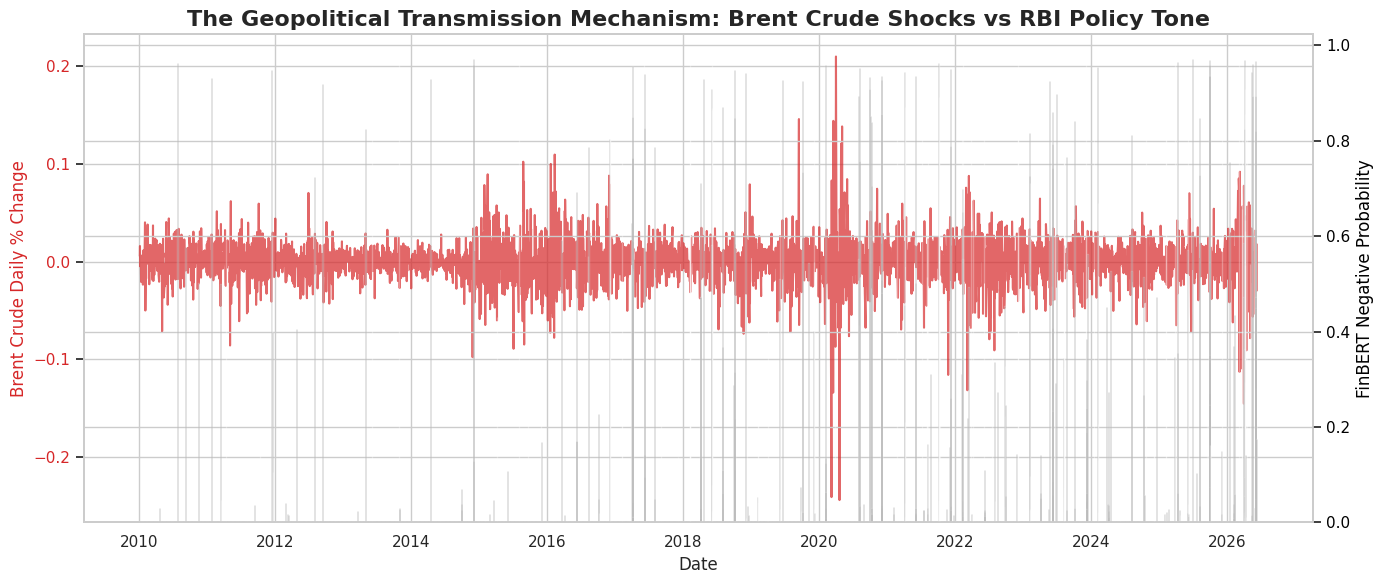

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings('ignore')

# Double-check that the directory is created at the start
if not os.path.exists('images'):
    os.makedirs('images')

# Set the visual style for a professional look
sns.set_theme(style="whitegrid")

print("Generating Professional Portfolio Visualizations...\n")

# =====================================================================
# VISUALIZATION 1: Macro Shock Dual-Axis Line Chart (The VAR Story)
# Shows how Oil Volatility spikes, followed by RBI negative sentiment
# =====================================================================
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Brent Crude Returns (Red Line)
ax1.plot(model_df['Date'], model_df['Crude_Return'], color='#D62728', alpha=0.7, linewidth=1.5, label='Brent Crude Volatility')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Brent Crude Daily % Change', color='#D62728', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#D62728')

# Plot 2: RBI Negative Sentiment (Black Bars overlay)
ax2 = ax1.twinx()
ax2.bar(model_df['Date'], model_df['War_Neg'], color='black', alpha=0.3, width=3, label='RBI Hawkish/Negative Sentiment')
ax2.set_ylabel('FinBERT Negative Probability', color='black', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')

plt.title('The Geopolitical Transmission Mechanism: Brent Crude Shocks vs RBI Policy Tone', fontsize=16, fontweight='bold')
fig.tight_layout()

# SAVE IMAGE 1
plt.savefig('images/sentiment_vs_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

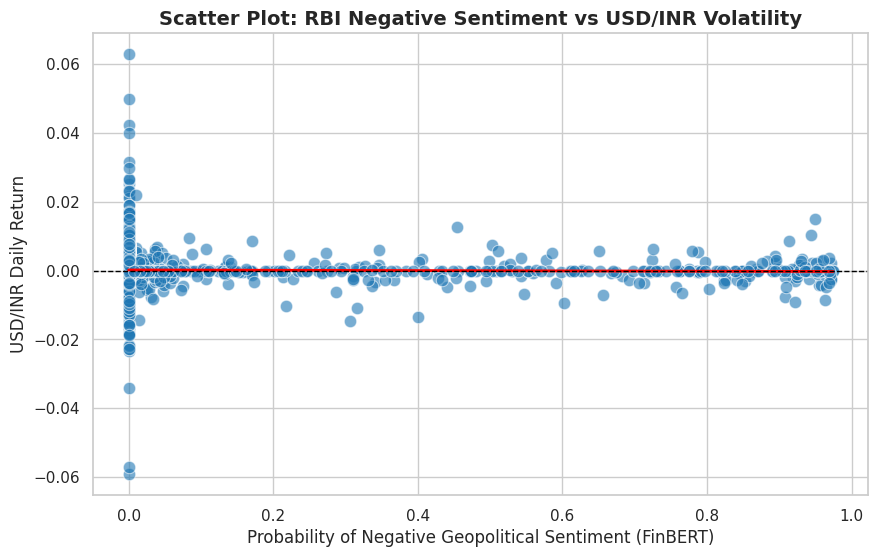

In [23]:
# =====================================================================
# VISUALIZATION 2: Sentiment vs Volatility Scatter Plot
# Shows the exact correlation cluster between tone and market reaction
# =====================================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=model_df, x='War_Neg', y='USD_INR_Return', color='#1F77B4', alpha=0.6, s=80)

# Add a trend line
sns.regplot(data=model_df, x='War_Neg', y='USD_INR_Return', scatter=False, color='red', line_kws={"linewidth": 2})

plt.title('Scatter Plot: RBI Negative Sentiment vs USD/INR Volatility', fontsize=14, fontweight='bold')
plt.xlabel('Probability of Negative Geopolitical Sentiment (FinBERT)', fontsize=12)
plt.ylabel('USD/INR Daily Return', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Neutral zero line
plt.savefig('images/sentiment_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

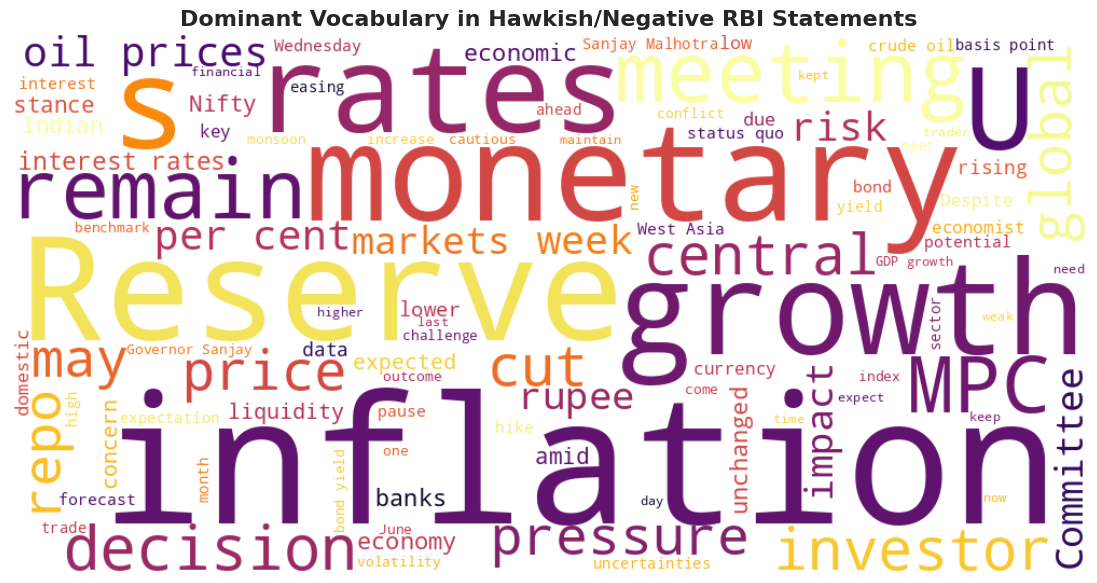

In [24]:
# =====================================================================
# VISUALIZATION 3: The Geopolitical Word Clouds
# What specific words was the RBI using when they were worried?
# =====================================================================
# We isolate the text from articles where FinBERT labeled the sentiment as Negative
negative_articles = df_geo_final[df_geo_final['War_Sentiment_Label'] == 'Negative']['summary'].astype(str)
negative_text = " ".join(negative_articles)

# We define a strict list of Stopwords for the visual so it looks clean
# We add common web scraping noise words to the standard list
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['said', 'will', 'say', 'india', 'rbi', 'bank', 'rate', 'policy', 'market', 'year', 'percent'])

# Generate the Word Cloud
if len(negative_text.strip()) > 0:
    wordcloud_neg = WordCloud(width=1000, height=500,
                              background_color='white',
                              stopwords=custom_stopwords,
                              colormap='inferno', # 'inferno' gives a great red/orange "warning" look
                              max_words=100).generate(negative_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud_neg, interpolation='bilinear')
    plt.axis('off')
    plt.title('Dominant Vocabulary in Hawkish/Negative RBI Statements', fontsize=16, fontweight='bold')
    plt.savefig('images/negative_wordcloud.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Not enough purely negative text to generate a word cloud.")